# California Buoys Example

This notebook demonstrates a regional historical-data workflow for NDBC buoys near California. It starts with the full station catalog, filters stations by geographic bounds, fetches monthly historical observations, and summarizes water-temperature coverage across stations.

The workflow makes live requests to NDBC data services, so execution time and available stations can vary as the upstream catalog changes.


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xndbc
from helpers import compute_data_coverage, plot_stations

/Users/anthonymeza/miniforge3/envs/xbuoy-test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Station Catalog

Start by importing the analysis tools and requesting the full NDBC station catalog. The station catalog is returned as an `xarray.Dataset`, which makes it convenient to filter, plot, and align with downloaded observations later in the workflow.


In [2]:
# Get all NDBC buoy stations
buoy_stations = xndbc.list_available(mode=None)

## Plot All Station Locations

Before filtering to a region, plot the full station catalog to check the geographic coverage of the source data. This gives context for the later California subset.


Text(0.5, 1.0, 'All NDBC Buoys')

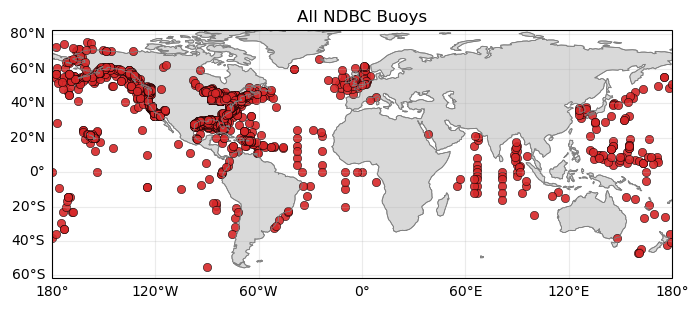

In [3]:
fig, ax = plot_stations(buoy_stations, add_labels = False)
ax.set_title("All NDBC Buoys")

## Filter to California-Area Stations

Use longitude and latitude bounds to select buoys near California. The filtered station dataset is plotted immediately so the selected spatial domain can be checked visually before downloading observations.


Text(0.5, 1.0, 'All NDBC Buoys near California')

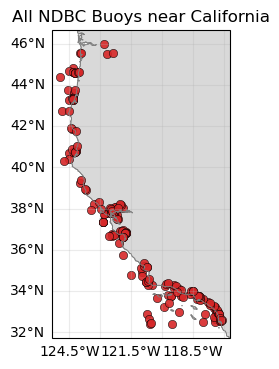

In [4]:
# Filter for California stations
california_buoys = xndbc.list_available(
    mode=None,
    lon_min=-125,
    lon_max=-115,
    lat_min=20,
    lat_max=46,
)
fig, ax = plot_stations(california_buoys, add_labels = False)
ax.set_title("All NDBC Buoys near California")

## Fetch Historical Observations

Fetch monthly historical observations for the selected California stations between 1998 and 2000. The returned dataset is then used to compute data coverage, sort stations by latitude, and compare water-temperature records across the region.


In [5]:
# Define years to retrieve data for
years = range(1998, 2000)

# Get list of California station IDs
station_list = california_buoys.station_id.values.tolist()

# Fetch historical data using the public xarray API
data = xndbc.fetch_data(
    station_ids=station_list,
    years=years,
    sample_rate="M",  # Monthly averages
)

coverage = compute_data_coverage(data)

Fetching stations: 100%|██████████| 192/192 [00:05<00:00, 35.95station/s] 


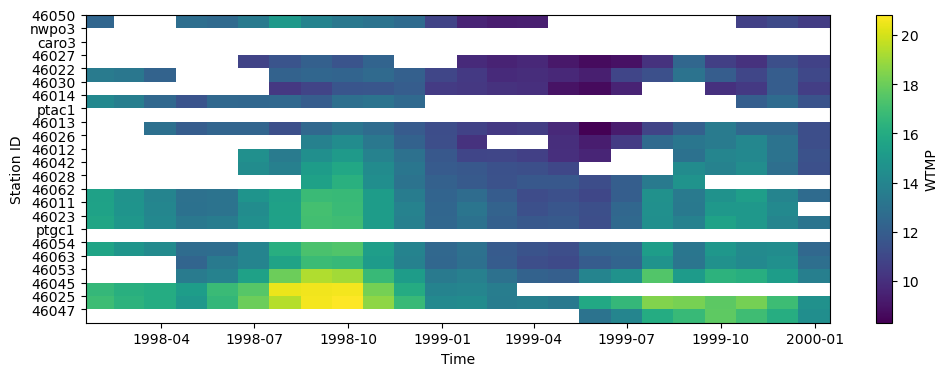

In [6]:
sorted_data = data.sortby("latitude")

station_idx = np.arange(len(sorted_data["WTMP"].station_id))

plt.figure(figsize=(12, 4))
plt.pcolormesh(sorted_data["WTMP"].time, station_idx, sorted_data["WTMP"], cmap="viridis", shading="auto")
plt.yticks(station_idx + 0.5, sorted_data["WTMP"].station_id.values)
plt.xlabel("Time"); plt.ylabel("Station ID"); plt.colorbar(label="WTMP")
plt.show()

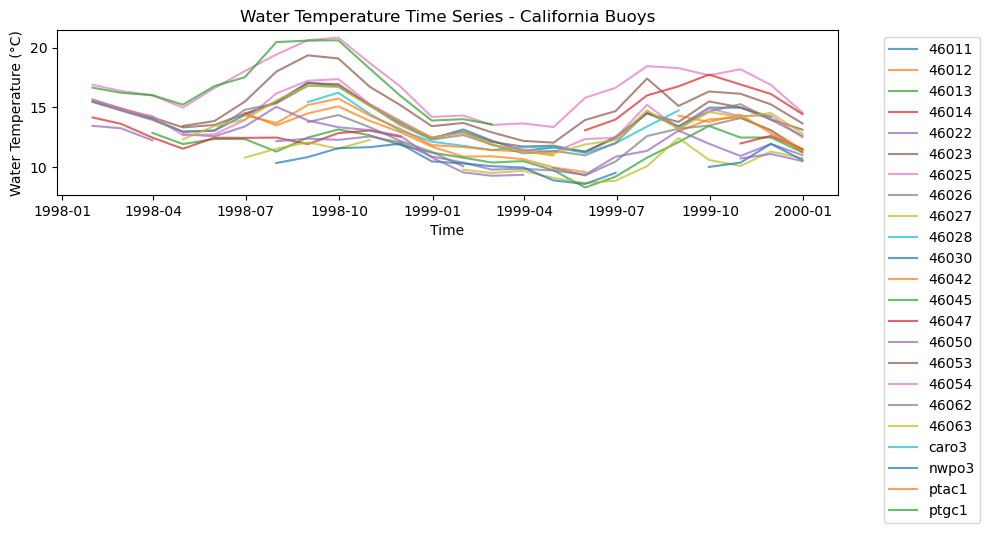

In [7]:
# Plot water temperature time series for all California buoys
fig, ax = plt.subplots(figsize=(10, 4))
for station in data["station_id"]:
    ax.plot(data.time, data.WTMP.sel(station_id=station), label=station.values, alpha=0.7)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("Time")
ax.set_ylabel("Water Temperature (°C)")
ax.set_title("Water Temperature Time Series - California Buoys")
plt.tight_layout()

Text(0.5, 1.0, 'Water Temperature Data Coverage - California Buoys')

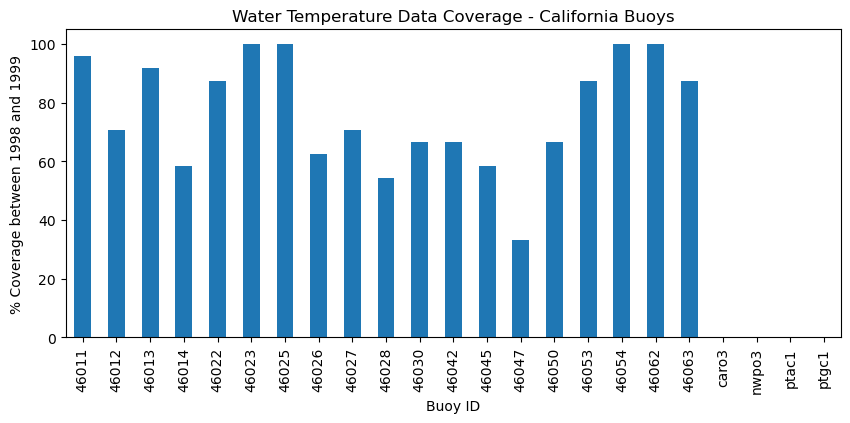

In [8]:
# Plot data coverage for each station
fig, ax = plt.subplots(figsize=(10, 4))
coverage["WTMP_coverage"].to_series().plot.bar(ax=ax)
ax.set_xlabel("Buoy ID")
ax.set_ylabel(f"% Coverage between {years[0]} and {years[-1]}")
ax.set_title("Water Temperature Data Coverage - California Buoys")

In [9]:
# Save the dataset to NetCDF file
# data.to_netcdf("NDBC_California_Daily.nc")
# print(f"Saved data for {len(data.station_id)} California buoys to NDBC_California_Daily.nc")